**Architecture:**

CSV (network logs) → Pandas → Feature Engineering → Anomaly Detection → Dashboard

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv('/content/UNSW_NB15_training-set.csv')

In [3]:
# Select useful features
features = ['dur', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl']
df = df[features].dropna()

In [4]:
# Normalize data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [5]:
# Train anomaly detection model
model = IsolationForest(contamination=0.02, random_state=42)
df['anomaly'] = model.fit_predict(X_scaled)

In [6]:
# Convert -1 to anomaly
df['anomaly'] = df['anomaly'].map({1: 0, -1: 1})

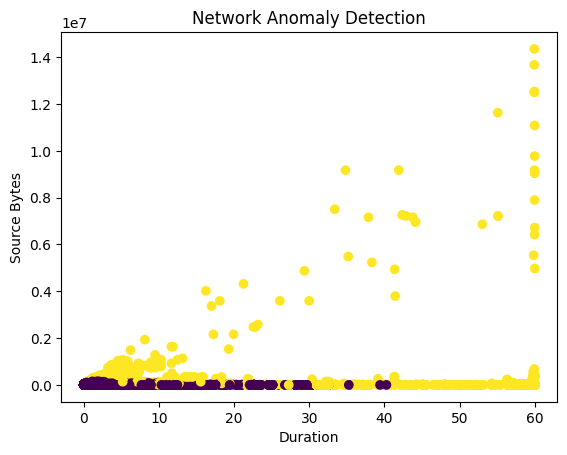

In [7]:
# Visualization
plt.figure()
plt.scatter(df['dur'], df['sbytes'], c=df['anomaly'])
plt.xlabel("Duration")
plt.ylabel("Source Bytes")
plt.title("Network Anomaly Detection")
plt.show()

In [8]:
# Save results
df.to_csv('/content/anomaly_output.csv', index=False)